# HAM10000 - EfficientNetB0 avec oversampling (CPU only) et fine-tuning complet

Notebook qui :
- charge HAM10000
- oversample le train
- entraîne EfficientNetB0 **entier** (fine-tuning complet) avec un petit learning rate
- évalue sur le set de validation


Version 1.1

date : 2025/11/17

In [ ]:
import os

# 1) Couper les logs verbeux (ne casse rien)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# 2) Désactiver oneDNN (sûr, évite du bruit)
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import tensorflow as tf

# 3) Désactiver les optimisations Grappler qui provoquent les messages
tf.config.optimizer.set_experimental_options({
    "layout_optimizer": False,
    "remapping": False,
    "constant_folding": True,
})

print("TF version:", tf.__version__)
print("Devices:", tf.config.list_physical_devices())


TF version: 2.17.0
Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:

from tensorflow.keras import layers, models
import warnings
warnings.filterwarnings("ignore")
import random

#os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # CPU only

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)


print("TensorFlow:", tf.__version__)
print("GPUs visibles:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.17.0
GPUs visibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
base_dir = os.getcwd()

metadata_path = os.path.join(base_dir, "data", "HAM10000_metadata.csv")
img_dir_1 = os.path.join(base_dir, "data", "HAM10000_images_part_1")
img_dir_2 = os.path.join(base_dir, "data", "HAM10000_images_part_2")

print("Base dir:", base_dir)
print("Metadata path:", metadata_path)
print("Images part 1:", img_dir_1)
print("Images part 2:", img_dir_2)


Base dir: /workspace
Metadata path: /workspace/data/HAM10000_metadata.csv
Images part 1: /workspace/data/HAM10000_images_part_1
Images part 2: /workspace/data/HAM10000_images_part_2


In [7]:
metadata = pd.read_csv(metadata_path)
print("Metadata loaded:", metadata.shape)
metadata.head()


Metadata loaded: (10015, 7)


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [8]:
all_image_dirs = [img_dir_1, img_dir_2]
image_paths = []

for d in all_image_dirs:
    if not os.path.isdir(d):
        continue
    for fname in sorted(os.listdir(d)):
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            image_paths.append(os.path.join(d, fname))

print("Images trouvées:", len(image_paths))
image_paths[:5]


Images trouvées: 10015


['/workspace/data/HAM10000_images_part_1/ISIC_0024306.jpg',
 '/workspace/data/HAM10000_images_part_1/ISIC_0024307.jpg',
 '/workspace/data/HAM10000_images_part_1/ISIC_0024308.jpg',
 '/workspace/data/HAM10000_images_part_1/ISIC_0024309.jpg',
 '/workspace/data/HAM10000_images_part_1/ISIC_0024310.jpg']

In [9]:
rows = []
for path in image_paths:
    image_id = os.path.splitext(os.path.basename(path))[0]
    row = metadata.loc[metadata["image_id"] == image_id, "dx"]
    if not row.empty:
        rows.append({"image_path": path, "dx": row.values[0]})
    else:
        rows.append({"image_path": path, "dx": "unknown"})

df = pd.DataFrame(rows)
print(df["dx"].value_counts())
df.head()


dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


,image_path,dx
0,/workspace/data/HAM10000_images_part_1/ISIC_00...,nv
1,/workspace/data/HAM10000_images_part_1/ISIC_00...,nv
2,/workspace/data/HAM10000_images_part_1/ISIC_00...,nv
3,/workspace/data/HAM10000_images_part_1/ISIC_00...,nv
4,/workspace/data/HAM10000_images_part_1/ISIC_00...,mel


In [10]:
df = df[df["dx"] != "unknown"].reset_index(drop=True)
print("Après filtrage unknown:", df.shape)
print(df["dx"].value_counts())


Après filtrage unknown: (10015, 2)
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [11]:
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["dx"])

class_names = list(label_encoder.classes_)
n_classes = len(class_names)

print("Classes:", class_names)
print({i: c for i, c in enumerate(class_names)})


Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
{0: 'akiec', 1: 'bcc', 2: 'bkl', 3: 'df', 4: 'mel', 5: 'nv', 6: 'vasc'}


In [12]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED,
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED,
)

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)
print("\nTrain distrib:\n", train_df["dx"].value_counts())
print("\nVal distrib:\n", val_df["dx"].value_counts())
print("\nTest distrib:\n", test_df["dx"].value_counts())


Train: (7010, 3)
Val: (1502, 3)
Test: (1503, 3)

Train distrib:
 dx
nv       4693
mel       779
bkl       769
bcc       360
akiec     229
vasc       99
df         81
Name: count, dtype: int64

Val distrib:
 dx
nv       1006
mel       167
bkl       165
bcc        77
akiec      49
vasc       21
df         17
Name: count, dtype: int64

Test distrib:
 dx
nv       1006
mel       167
bkl       165
bcc        77
akiec      49
vasc       22
df         17
Name: count, dtype: int64


In [14]:
def make_oversampled_df(df_in, label_col="label", seed=42):
    counts = df_in[label_col].value_counts()
    max_count = counts.max()
    print("Counts avant oversampling:\n", counts)

    dfs = []
    for label, count in counts.items():
        subset = df_in[df_in[label_col] == label]
        if count < max_count:
            subset_over = subset.sample(max_count, replace=True, random_state=seed)
        else:
            subset_over = subset
        dfs.append(subset_over)

    df_bal = pd.concat(dfs).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    print("\nCounts après oversampling:\n", df_bal[label_col].value_counts())
    return df_bal

train_df_bal = make_oversampled_df(train_df, label_col="label", seed=SEED)


Counts avant oversampling:
 label
5    4693
4     779
2     769
1     360
0     229
6      99
3      81
Name: count, dtype: int64

Counts après oversampling:
 label
4    4693
6    4693
2    4693
1    4693
5    4693
3    4693
0    4693
Name: count, dtype: int64


In [15]:
IMAGE_SIZE = 224
CHANNELS = 3
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize(img, (IMAGE_SIZE, IMAGE_SIZE))
    return img, label

def make_dataset(df_in, shuffle=False):
    paths = df_in["image_path"].values
    labels = df_in["label"].values.astype(np.int32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df_in), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_df_bal, shuffle=True)
val_ds = make_dataset(val_df, shuffle=False)
test_ds = make_dataset(test_df, shuffle=False)


I0000 00:00:1763140320.561780   26285 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:02:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1763140320.561813   26285 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:02:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1763140320.561822   26285 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:02:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1763140320.667453   26285 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:02:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1763140320.667507   26285 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:02:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

In [16]:
data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal_and_vertical"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1),
    ],
    name="data_augmentation",
)


In [23]:
# choix du modèle -> https://www.sabrepc.com/blog/deep-learning-and-ai/image-classification-models-transformers-cnns-and-hybridabs
#                    ainsi que chatgpt (mieux adapté car le dataset est petit (10015 entrées)

base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS),
    pooling="avg",
)
base_model.trainable = True  # fine-tuning complet

base_model.summary()


Model: "efficientnetb0"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 rescaling_1 (Rescaling)     (None, 224, 224, 3)          0         ['input_3[0][0]']             
                                                                                                  
 normalization_1 (Normaliza  (None, 224, 224, 3)          7         ['rescaling_1[0][0]']         
 tion)                                                                                            
                                                                                                  
 tf.math.multiply_1 (TFOpLa  (None, 224, 224, 3)          0         ['normalization_1

In [18]:
inputs = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS))
x = data_augmentation(inputs)
x = base_model(x, training=True)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(n_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs, name="EffNetB0_full_finetune")
model.summary()


Model: "EffNetB0_full_finetune"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 data_augmentation (Sequent  (None, 224, 224, 3)       0         
 ial)                                                            
                                                                 
 efficientnetb0 (Functional  (None, 1280)              4049571   
 )                                                               
                                                                 
 dropout (Dropout)           (None, 1280)              0         
                                                                 
 dense (Dense)               (None, 7)                 8967      
                                                                 
Total params: 4058538 (15.48 MB)
Trainable p

In [19]:
metrics_list = [
    "accuracy",
    tf.keras.metrics.SparseCategoricalAccuracy(name="sparse_acc"),
]

lr = 1e-4
optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=metrics_list,
)


In [ ]:
# Callbacks de base
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=5,
    restore_best_weights=True,
    verbose=1,
)

checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    "best_model_full_finetune.keras",
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    verbose=1,
)

# Ajouter la classe du callback
from sklearn.metrics import classification_report
import numpy as np

class PerClassRecallCallback(tf.keras.callbacks.Callback):
    def __init__(self, val_data, class_names):
        super().__init__()
        self.val_data = val_data
        self.class_names = class_names

    def on_epoch_end(self, epoch, logs=None):
        y_true = []
        y_pred = []

        # Collecte des labels et prédictions
        for X, y in self.val_data:
            preds = self.model.predict(X, verbose=0)
            y_true.extend(y.numpy())
            y_pred.extend(np.argmax(preds, axis=1))

        # Rapport sklearn
        report = classification_report(
            y_true,
            y_pred,
            target_names=self.class_names,
            output_dict=True
        )

        # Affichage lisible
        print("\n--- Recall par classe ---")
        for cls in self.class_names:
            print(f"{cls:5s} : recall = {report[cls]['recall']:.4f}")
        print("-------------------------\n")


In [ ]:
# === V3 : class_weights "soft" pour booster les classes graves ===

# Rappel du mapping :
# 0: akiec, 1: bcc, 2: bkl, 3: df, 4: mel, 5: nv, 6: vasc

class_weights = {
    0: 1.8,  # akiec  (grave, rare)
    1: 1.5,  # bcc    (grave)
    2: 1.0,  # bkl    (neutre)
    3: 1.8,  # df     (rare)
    4: 2.5,  # mel    ← priorité max
    5: 0.8,  # nv     (très fréquent, bénin)
    6: 1.8,  # vasc   (rare)
}

print("Class weights V3 utilisés :")
for k, v in class_weights.items():
    print(f"classe {k} : {v}")


Class weights V3 utilisés :
classe 0 : 1.8
classe 1 : 1.5
classe 2 : 1.0
classe 3 : 1.8
classe 4 : 2.5
classe 5 : 0.8
classe 6 : 1.8


In [22]:
EPOCHS = 25

class_names = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

callbacks = [
    early_stopping,
    checkpoint_cb,
    PerClassRecallCallback(val_ds, class_names)
]


history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights,   # ← V3 : pondération activée
    verbose=1,
)


len(history.history["loss"]), history.history.keys()


Epoch 1/25


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

   1/1027 [..............................] - ETA: 4:56:57 - loss: 3.3961 - accuracy: 0.0312 - sparse_acc: 0.0312

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
W0000 00:00:1763140416.114547   26376 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1763140416.118248   26376 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1763140416.118622   26376 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1763140416.118827   26376 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1763140416.119425   26376 gpu_timer.cc:114] Skipping the delay kernel, measu

   4/1027 [..............................] - ETA: 1:30 - loss: 3.1253 - accuracy: 0.1953 - sparse_acc: 0.1953   

...

W0000 00:00:1763140987.806070   26369 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1763140987.806254   26369 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1763140987.806391   26369 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1763140987.806498   26369 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1763140987.806653   26369 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1763140987.806842   26369 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1763140987.807092   26369 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1763140987.807436   26369 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1763140987.807986   26369 gp


--- Recall par classe ---
akiec : recall = 0.6939
bcc   : recall = 0.8182
bkl   : recall = 0.5879
df    : recall = 0.7647
mel   : recall = 0.7246
nv    : recall = 0.4185
vasc  : recall = 1.0000
-------------------------

1027/1027 [==============================] - 80s 78ms/step - loss: 0.1240 - accuracy: 0.9611 - sparse_acc: 0.9611 - val_loss: 1.9223 - val_accuracy: 0.5160 - val_sparse_acc: 0.5160
Epoch 8/25
   1/1027 [..............................] - ETA: 1:46 - loss: 0.0978 - accuracy: 0.9375 - sparse_acc: 0.9375

W0000 00:00:1763140990.643852   26365 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1763140990.644036   26365 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1763140990.644208   26365 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1763140990.644356   26365 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1763140990.644689   26365 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1763140990.644879   26365 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1763140990.645125   26365 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1763140990.645564   26365 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1763140990.646007   26365 gp

1027/1027 [==============================] - ETA: 0s - loss: 0.1118 - accuracy: 0.9651 - sparse_acc: 0.9651  
Epoch 8: val_loss did not improve from 1.86041

--- Recall par classe ---
akiec : recall = 0.6327
bcc   : recall = 0.7792
bkl   : recall = 0.6424
df    : recall = 0.7059
mel   : recall = 0.7246
nv    : recall = 0.4493
vasc  : recall = 0.9048
-------------------------

1027/1027 [==============================] - 81s 79ms/step - loss: 0.1118 - accuracy: 0.9651 - sparse_acc: 0.9651 - val_loss: 1.9709 - val_accuracy: 0.5320 - val_sparse_acc: 0.5320
Epoch 9/25
1027/1027 [==============================] - ETA: 0s - loss: 0.0910 - accuracy: 0.9719 - sparse_acc: 0.9719  
Epoch 9: val_loss did not improve from 1.86041

--- Recall par classe ---
akiec : recall = 0.7347
bcc   : recall = 0.8052
bkl   : recall = 0.6727
df    : recall = 0.8235
mel   : recall = 0.6826
nv    : recall = 0.4692
vasc  : recall = 0.9524
-------------------------

1027/1027 [==============================] - 80s 7

(11,
 dict_keys(['loss', 'accuracy', 'sparse_acc', 'val_loss', 'val_accuracy', 'val_sparse_acc']))

In [24]:
# === ÉVALUATION ACCURACY & RECALL (GLOBAL + PAR CLASSE) === #

from sklearn.metrics import accuracy_score, recall_score, classification_report
import numpy as np

class_names = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

# Récupère prédictions + labels réels sur le dataset de validation
y_true = []
y_pred = []

for X, y in val_ds:
    preds = model.predict(X, verbose=0)
    y_true.extend(y.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Accuracy globale
acc = accuracy_score(y_true, y_pred)
print(f"\nValidation Accuracy: {acc:.4f}")

# Recall globale (macro = moy. par classe)
recall_macro = recall_score(y_true, y_pred, average="macro")
print(f"Validation Recall (macro): {recall_macro:.4f}")

# Recall par classe
print("\n--- Recall par classe ---")
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)
print(report)



Validation Accuracy: 0.5373
Validation Recall (macro): 0.7254

--- Recall par classe ---
              precision    recall  f1-score   support

       akiec     0.3400    0.6939    0.4564        49
         bcc     0.3596    0.8312    0.5020        77
         bkl     0.4500    0.6000    0.5143       165
          df     0.1458    0.8235    0.2478        17
         mel     0.3159    0.7246    0.4400       167
          nv     0.9891    0.4523    0.6207      1006
        vasc     0.3077    0.9524    0.4651        21

    accuracy                         0.5373      1502
   macro avg     0.4154    0.7254    0.4638      1502
weighted avg     0.7825    0.5373    0.5711      1502



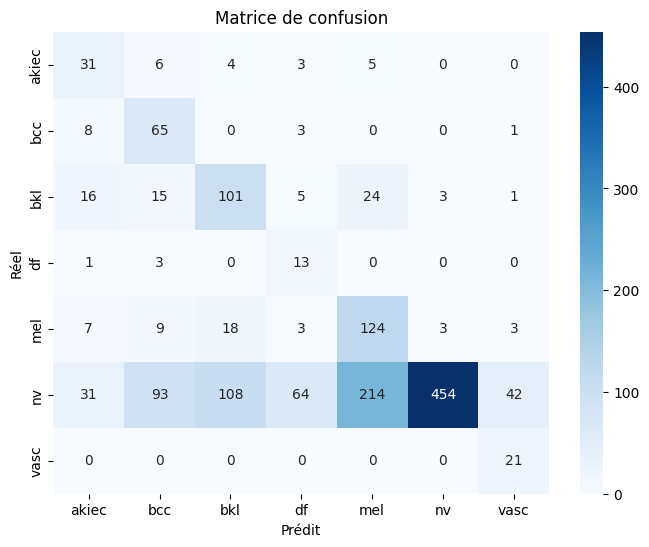

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Récupère les prédictions sur val_ds
y_true = []
y_pred = []

for X, y in val_ds:
    preds = model.predict(X, verbose=0)
    y_true.extend(y.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion")
plt.show()
